# Question 8: Feature Selection and Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE, RFECV
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

## 1. Setup and Exploratory Data Analysis

In [3]:
df = pd.read_csv('data/heart.csv')
print("Dataset Shape:", df.shape)
print(df.head())

X = df.drop('target', axis=1)
y = df['target']

X = pd.get_dummies(X, drop_first=True)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

Dataset Shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


## 2. Visualization: Feature Distributions and Correlation Matrix

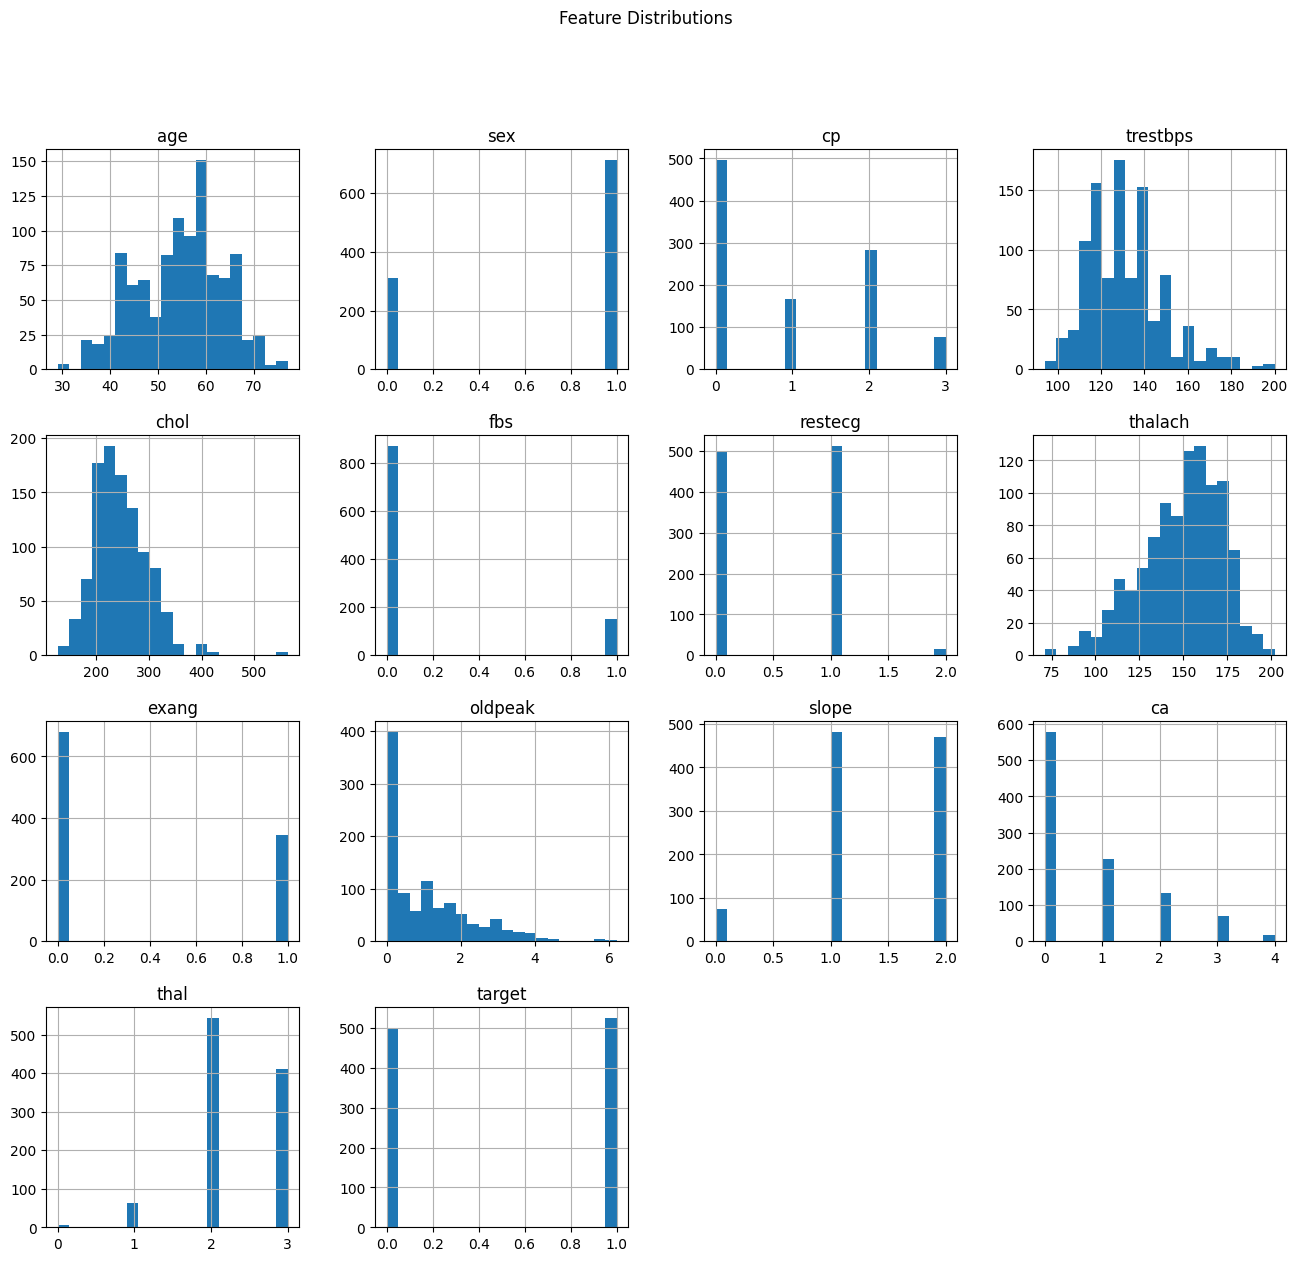

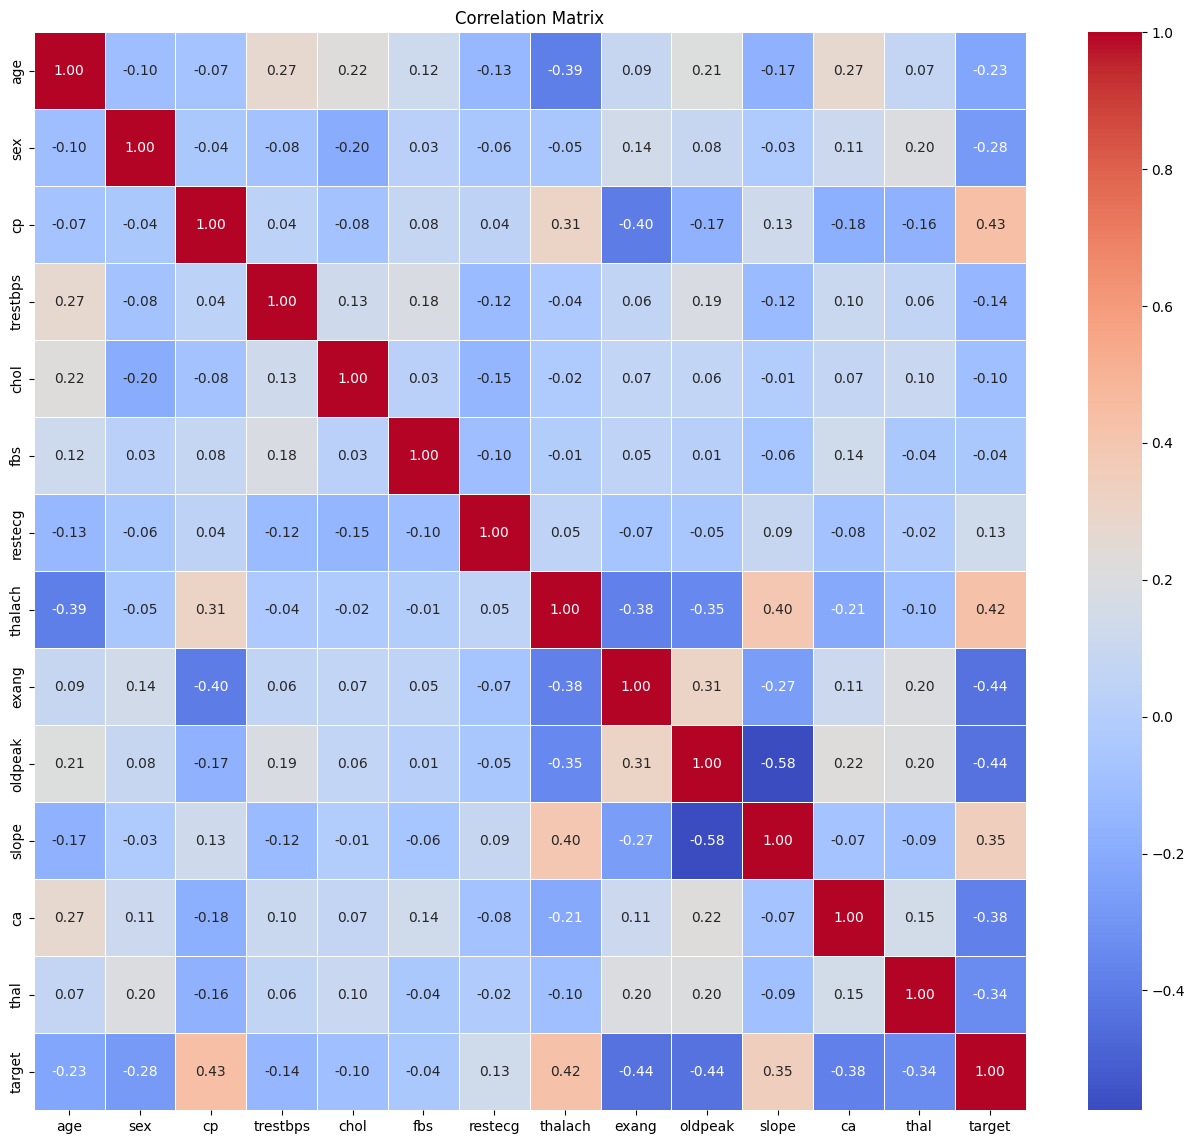

: 

In [ ]:
df.hist(figsize=(16, 14), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

plt.figure(figsize=(16, 14))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

## 3. Correlation-based Feature Filtering

In [5]:
corr_matrix_abs = corr_matrix.abs()
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("Features to remove based on high correlation (>0.85):", to_drop)

Features to remove based on high correlation (>0.85): []


## 4. Univariate Feature Selection (Mutual Information)

In [6]:
k = 5
selector_mi = SelectKBest(score_func=mutual_info_classif, k=k)
selector_mi.fit(X_scaled, y)
selected_indices_mi = selector_mi.get_support(indices=True)
selected_features_mi = [feature_names[i] for i in selected_indices_mi]

print("Top-k features selected by Mutual Information:", selected_features_mi)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

model_full = LogisticRegression(random_state=42)
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)

X_train_mi = X_train.iloc[:, selected_indices_mi]
X_test_mi = X_test.iloc[:, selected_indices_mi]

model_mi = LogisticRegression(random_state=42)
model_mi.fit(X_train_mi, y_train)
y_pred_mi = model_mi.predict(X_test_mi)
acc_mi = accuracy_score(y_test, y_pred_mi)

print(f"Accuracy with ALL features: {acc_full:.4f}")
print(f"Accuracy with Top-{k} Mutual Info features: {acc_mi:.4f}")

Top-k features selected by Mutual Information: ['cp', 'chol', 'thalach', 'oldpeak', 'thal']
Accuracy with ALL features: 0.8098
Accuracy with Top-5 Mutual Info features: 0.8244


## 5. Recursive Feature Elimination (RFE)

In [7]:
model_rfe_base = LogisticRegression(random_state=42, solver='liblinear')
rfe = RFE(estimator=model_rfe_base, n_features_to_select=k)
rfe.fit(X_train, y_train)

selected_features_rfe = [feature_names[i] for i in range(len(feature_names)) if rfe.support_[i]]
print("Features selected by RFE:", selected_features_rfe)

X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

model_rfe = LogisticRegression(random_state=42)
model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = model_rfe.predict(X_test_rfe)
acc_rfe = accuracy_score(y_test, y_pred_rfe)

print(f"Accuracy with Top-{k} RFE features: {acc_rfe:.4f}")

overlap = set(selected_features_mi).intersection(set(selected_features_rfe))
print("Overlap between MI and RFE:", overlap)

Features selected by RFE: ['sex', 'cp', 'exang', 'oldpeak', 'ca']
Accuracy with Top-5 RFE features: 0.8537
Overlap between MI and RFE: {'oldpeak', 'cp'}


## 6. RFE with Cross-Validation (RFECV)

Optimal number of features: 12
Selected features by RFECV: ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


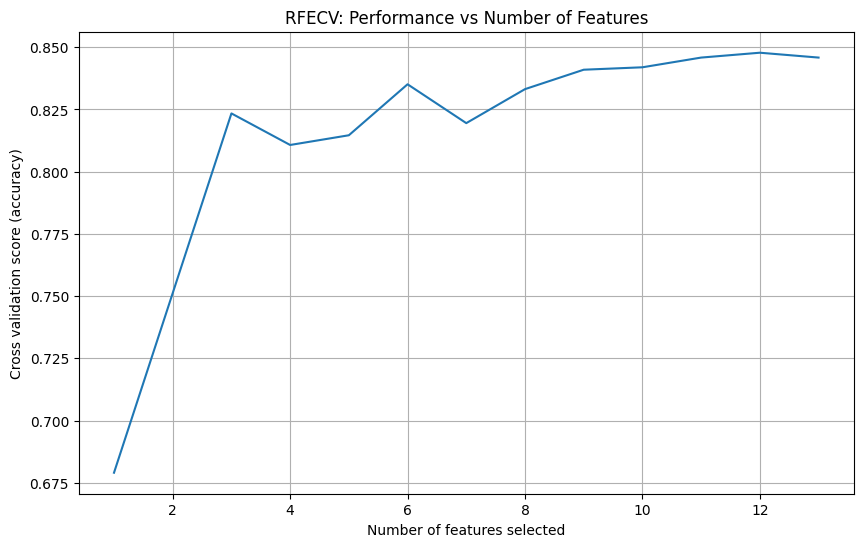

In [8]:
rfecv = RFECV(estimator=LogisticRegression(random_state=42, solver='liblinear'), step=1, cv=StratifiedKFold(5), scoring='accuracy')
rfecv.fit(X_scaled, y)

print("Optimal number of features: %d" % rfecv.n_features_)
print("Selected features by RFECV:", [feature_names[i] for i in range(len(feature_names)) if rfecv.support_[i]])

plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (accuracy)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.title("RFECV: Performance vs Number of Features")
plt.grid()
plt.show()

## 7. Embedded Method: L1 Regularization (Lasso)

Features selected by Lasso (non-zero coefficients): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Sparsity (Zero coefficients): 0


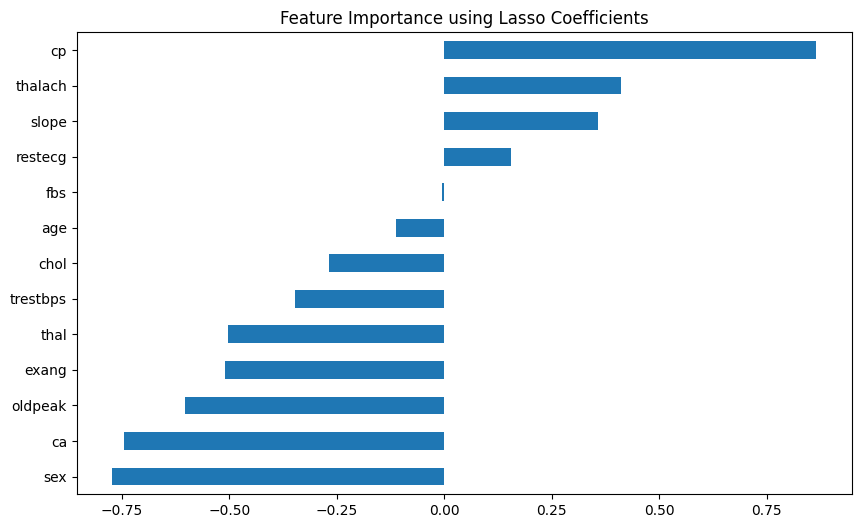

In [9]:
lasso = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', random_state=42)
lasso.fit(X_train, y_train)

lasso_coefs = pd.Series(lasso.coef_[0], index=feature_names)
selected_features_lasso = lasso_coefs[lasso_coefs != 0].index.tolist()

print("Features selected by Lasso (non-zero coefficients):", selected_features_lasso)
print("Sparsity (Zero coefficients):", (lasso_coefs == 0).sum())

plt.figure(figsize=(10, 6))
lasso_coefs.sort_values().plot(kind='barh')
plt.title("Feature Importance using Lasso Coefficients")
plt.show()

## 8. Principal Component Analysis (PCA)

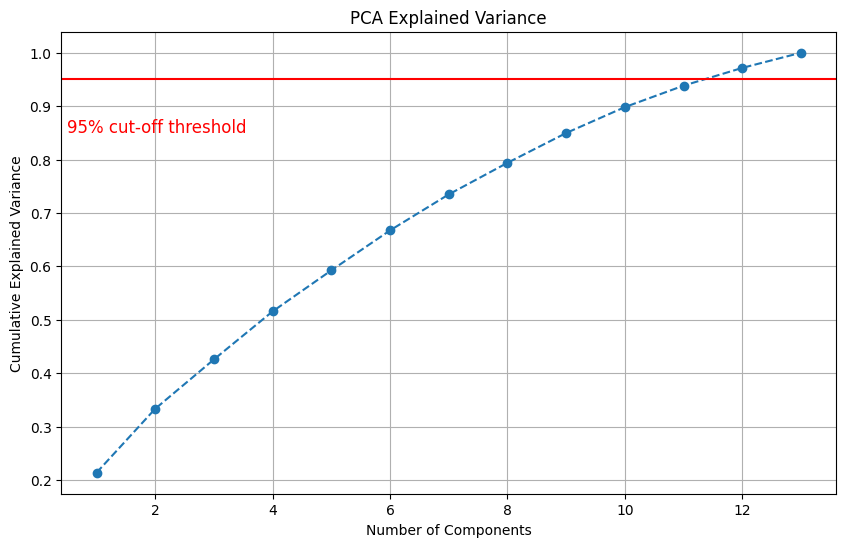

Number of components to explain 95% variance: 12


In [10]:
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=12)
plt.grid()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to explain 95% variance: {n_components_95}")